In [1]:
import duckdb
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

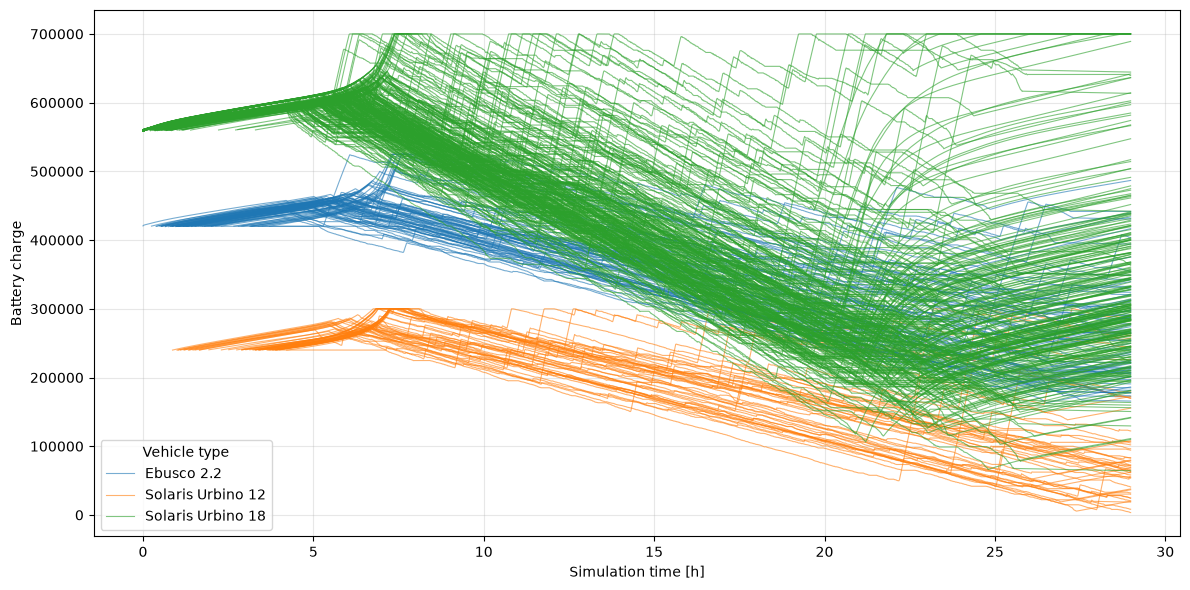

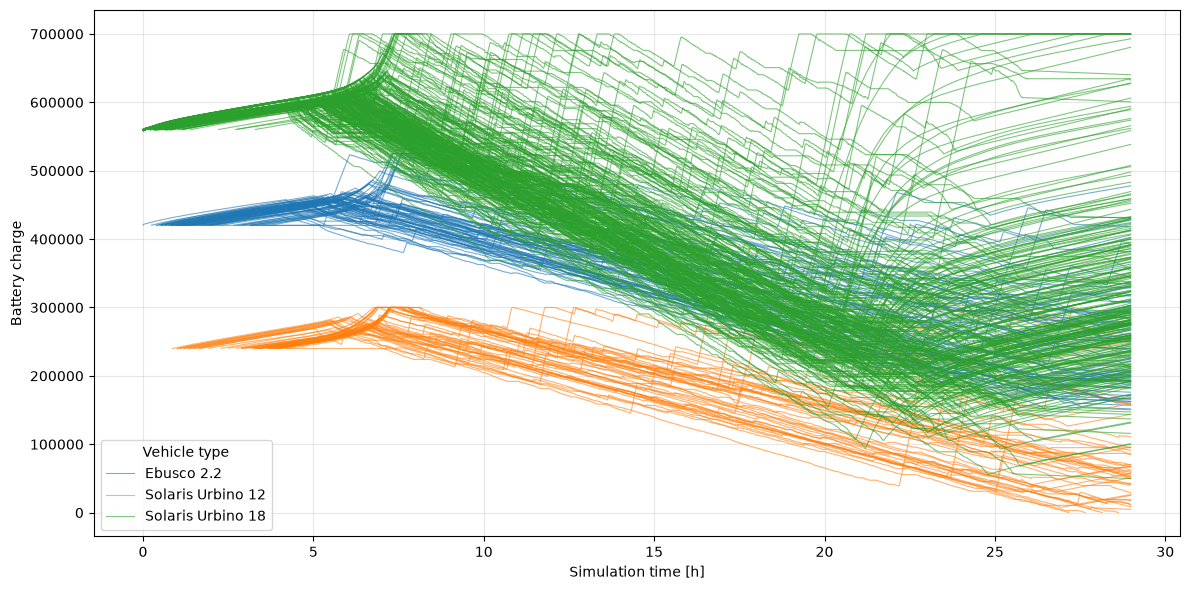

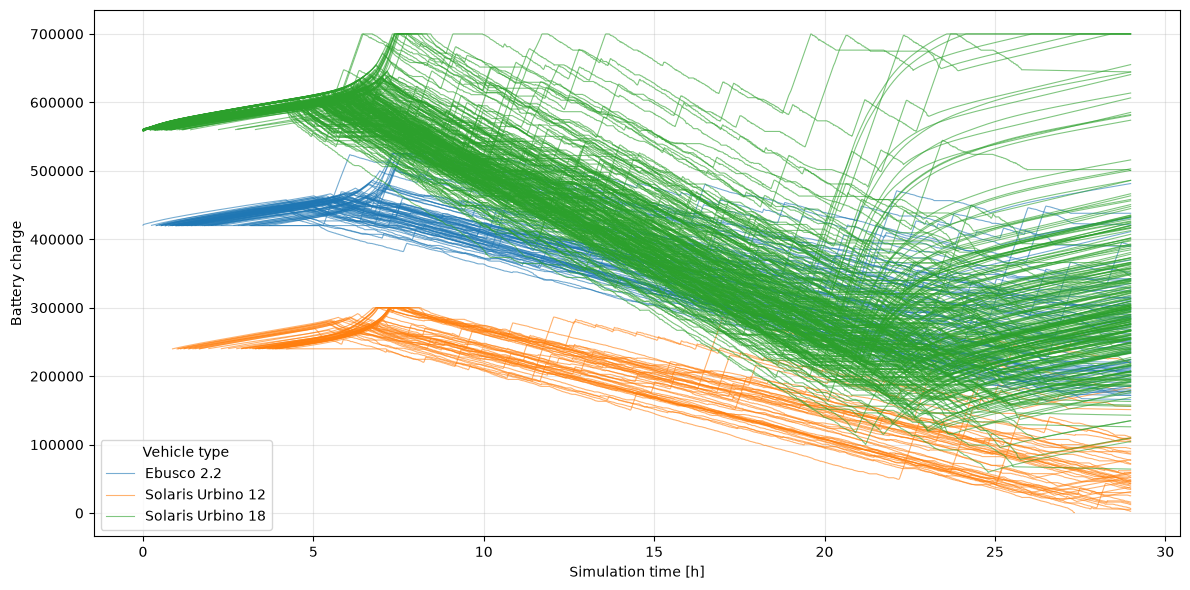

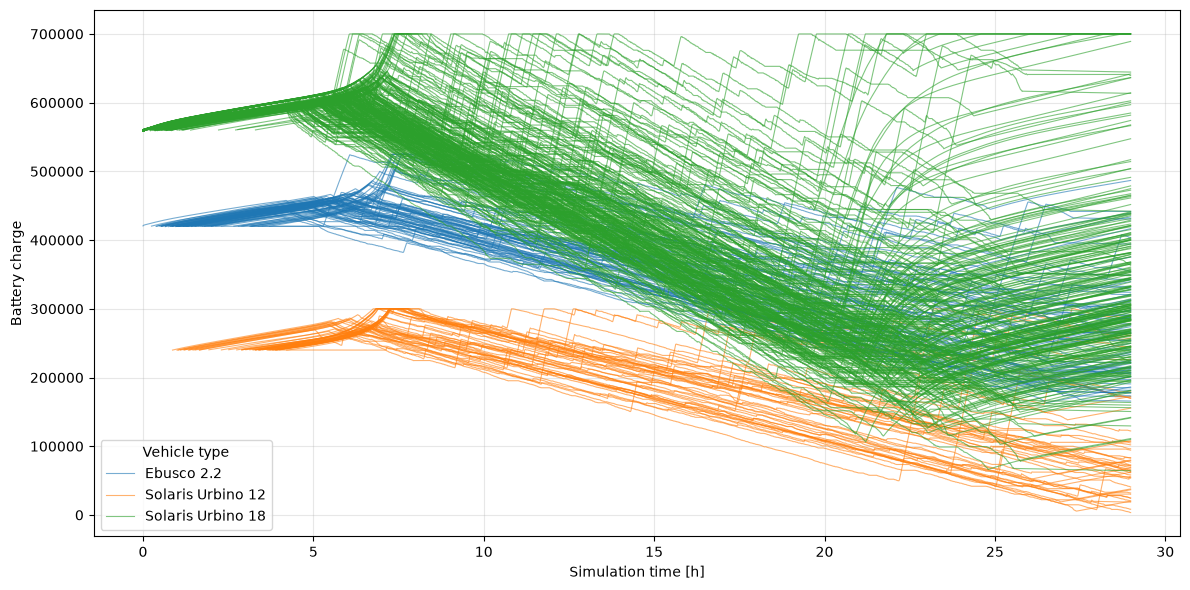

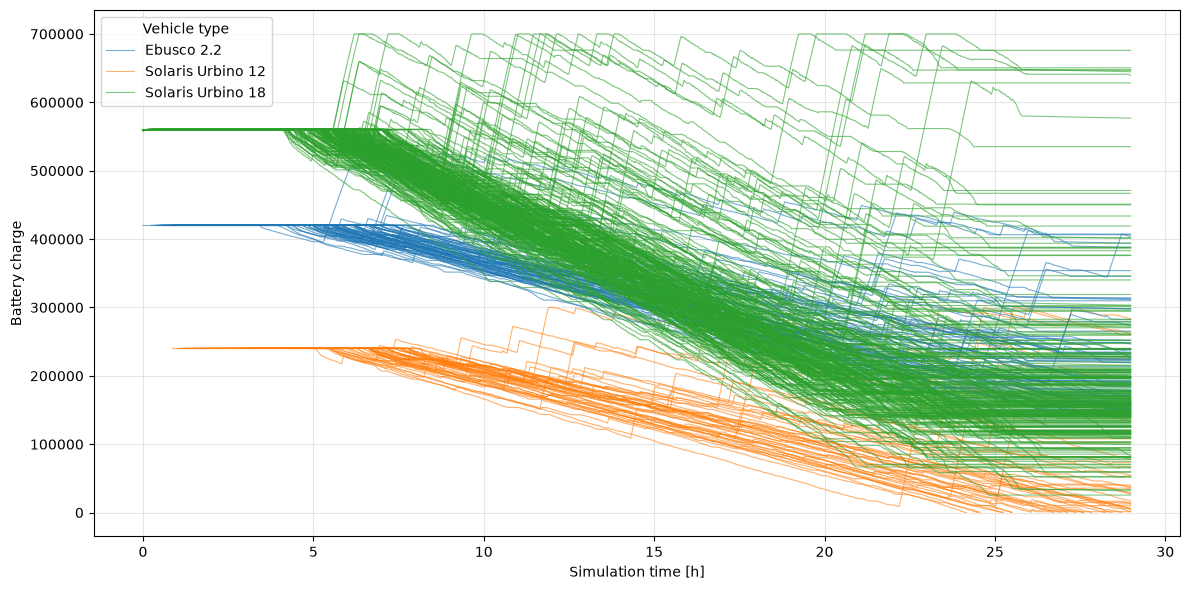

In [12]:
def plot_battery_charge(db_path, seed, save_dir=None):

    conn = duckdb.connect(db_path)

    query = """
        SELECT
            b.vehicle_id,
            b.timestep_time,
            b.vehicle_actualBatteryCapacity,
            b.scenario,
            t.tripinfo_vType
        FROM main.multirun_battery_aggregated AS b
        JOIN main.multirun_tripinfo AS t
            ON b.vehicle_id = t.tripinfo_id
            AND b.seed = t.seed
        WHERE b.seed = ?
        ORDER BY b.scenario, b.vehicle_id, b.timestep_time
    """

    df = conn.execute(query, [seed]).fetchdf()
    conn.close()

    vehicle_type_names = {
        "Ebusco2.2electric12m": "Ebusco 2.2",
        "SolarsisUrbino12electric": "Solaris Urbino 12",
        "SolarsisUrbino18electric": "Solaris Urbino 18",
    }

    for scenario in ["summer", "winter", "reduced", "storage", "nodepot"]:

        subset = df[df["scenario"] == scenario]

        if subset.empty:
            continue

        fig, ax = plt.subplots(figsize=(12, 6))

        # Assign default Matplotlib colors by vehicle type.
        vtypes = subset["tripinfo_vType"].unique()
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        color_map = {
            vtype: colors[i % len(colors)]
            for i, vtype in enumerate(vtypes)
        }

        # Only add each vehicle type to the legend once.
        labeled_vtypes = set()

        for vehicle_id, vehicle in subset.groupby("vehicle_id"):

            vtype = vehicle["tripinfo_vType"].iloc[0]

            label = (
                vehicle_type_names.get(vtype, vtype)
                if vtype not in labeled_vtypes
                else None
            )

            ax.plot(
                vehicle["timestep_time"] / 3600,
                vehicle["vehicle_actualBatteryCapacity"],
                color=color_map[vtype],
                linewidth=0.8,
                alpha=0.6,
                label=label,
            )

            labeled_vtypes.add(vtype)

        ax.set_xlabel("Simulation time [h]")
        ax.set_ylabel("Battery charge")

        ax.grid(True, alpha=0.3)
        ax.legend(title="Vehicle type")

        fig.tight_layout()

        if save_dir is not None:
            save_dir = Path(save_dir)
            save_dir.mkdir(parents=True, exist_ok=True)

            fig.savefig(
                save_dir / f"battery_charge_{scenario}_seed_{seed}.png",
                dpi=150,
                bbox_inches="tight",
            )

        plt.show()

plot_battery_charge(db_path=r"./eBuS.duckdb", seed=65,save_dir=r"C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\Plots")